In [7]:
!pip install efficientnet_pytorch kaggle mediapipe streamlit plotly -q

In [6]:
!unzip -q archive.zip -d fer2013_data
!ls fer2013_data

test  train


Using: cuda
Train: 28709 | Val: 7178
Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Loaded pretrained weights for efficientnet-b0

PHASE 1: Training Classification Head
Epoch  1/10 | Loss: 1.8696 | Val Acc: 0.3188
Epoch  2/10 | Loss: 1.8391 | Val Acc: 0.3136
Epoch  3/10 | Loss: 1.8335 | Val Acc: 0.3229
Epoch  4/10 | Loss: 1.8158 | Val Acc: 0.3232
Epoch  5/10 | Loss: 1.8106 | Val Acc: 0.3201
Epoch  6/10 | Loss: 1.8097 | Val Acc: 0.3249
Epoch  7/10 | Loss: 1.7986 | Val Acc: 0.3324
Epoch  8/10 | Loss: 1.7975 | Val Acc: 0.3254
Epoch  9/10 | Loss: 1.7914 | Val Acc: 0.3373
Epoch 10/10 | Loss: 1.7909 | Val Acc: 0.3399
Phase 1 saved.

PHASE 2: Fine-Tuning Last 40 Backbone Layers
Epoch  1/30 | Loss: 1.7645 | Train: 0.3052 | Val: 0.3554
  ✓ Best model saved (0.3554)
Epoch  2/30 | Loss: 1.7332 | Train: 0.3197 | Val: 0.3638
  ✓ Best model saved (0.3638)
Epoch  3/30 | Loss: 1.7060 | Train: 0.3385 | Val: 0.3731
  ✓ Best model saved (0.3731)
Epoch  4/30 | Loss: 1.6780 | 

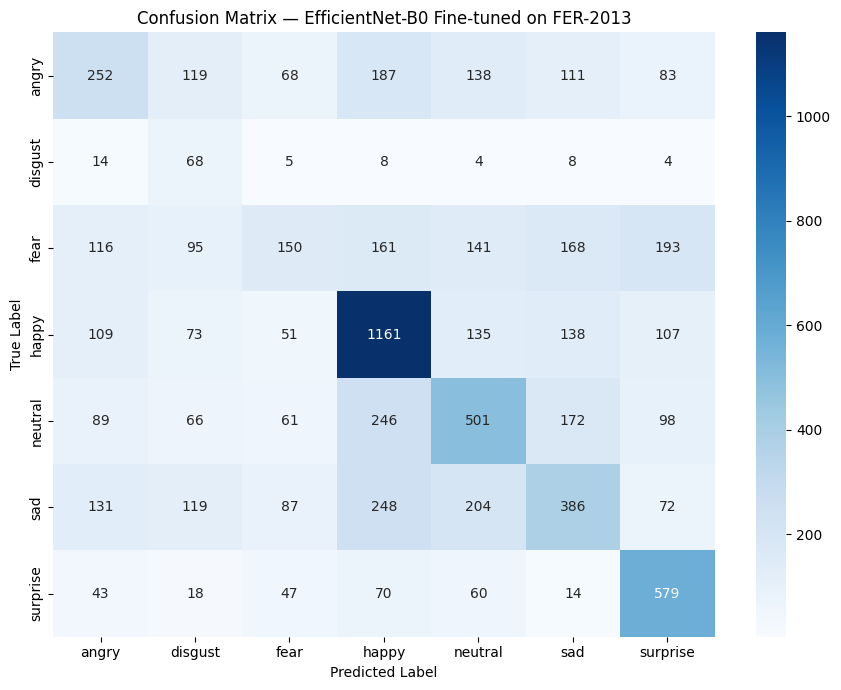

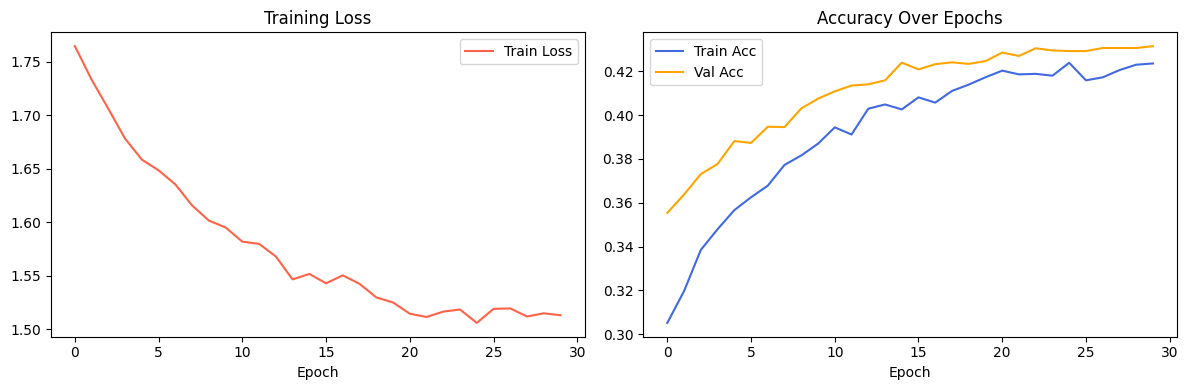


Done. Download: emofocus_model.pth, confusion_matrix.png, training_curves.png


In [10]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, WeightedRandomSampler
from efficientnet_pytorch import EfficientNet
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt

# ── Config ────────────────────────────────────────────────────────
DATA_DIR        = "fer2013_data"   # change if your folder name is different
BATCH_SIZE      = 64               # larger batch = faster + more stable
EPOCHS_HEAD     = 10
EPOCHS_FINETUNE = 30
LR_HEAD         = 1e-3
LR_FINETUNE     = 5e-5
DEVICE          = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EMOTIONS        = ['angry','disgust','fear','happy','neutral','sad','surprise']
print(f"Using: {DEVICE}")

# ── Transforms ────────────────────────────────────────────────────
transform_train = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

transform_val = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

# ── Datasets ──────────────────────────────────────────────────────
train_data = datasets.ImageFolder(os.path.join(DATA_DIR, "train"), transform=transform_train)
val_data   = datasets.ImageFolder(os.path.join(DATA_DIR, "test"),  transform=transform_val)
print(f"Train: {len(train_data)} | Val: {len(val_data)}")
print(f"Classes: {train_data.classes}")

# ── Weighted sampler for class imbalance ──────────────────────────
class_counts   = np.array([len(os.listdir(os.path.join(DATA_DIR, "train", c))) for c in train_data.classes])
class_weights  = 1.0 / class_counts
sample_weights = [class_weights[label] for _, label in train_data.samples]
sampler        = WeightedRandomSampler(sample_weights, len(sample_weights))

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, sampler=sampler, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_data,   batch_size=BATCH_SIZE, shuffle=False,   num_workers=2, pin_memory=True)

# ── Model ─────────────────────────────────────────────────────────
model = EfficientNet.from_pretrained('efficientnet-b0')

# Freeze all backbone
for param in model.parameters():
    param.requires_grad = False

# Custom 7-class head
in_features = model._fc.in_features
model._fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(in_features, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, 7)
)
model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss()

# ── Helper: evaluate on validation set ───────────────────────────
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            out    = model(imgs)
            preds  = out.argmax(1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    acc = correct / total
    return acc, all_preds, all_labels

# ── PHASE 1: Train head only ──────────────────────────────────────
print("\n" + "="*50)
print("PHASE 1: Training Classification Head")
print("="*50)

optimizer = torch.optim.Adam(model._fc.parameters(), lr=LR_HEAD)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

for epoch in range(EPOCHS_HEAD):
    model.train()
    total_loss, correct = 0, 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(imgs), labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct    += (model(imgs).argmax(1) == labels).sum().item()
    val_acc, _, _ = evaluate(model, val_loader)
    scheduler.step()
    print(f"Epoch {epoch+1:2d}/{EPOCHS_HEAD} | Loss: {total_loss/len(train_loader):.4f} | Val Acc: {val_acc:.4f}")

torch.save(model.state_dict(), "emofocus_phase1.pth")
print("Phase 1 saved.")

# PHASE 2: Unfreeze last 40 layers and fine-tune
print("\n" + "="*50)
print("PHASE 2: Fine-Tuning Last 40 Backbone Layers")
print("="*50)

all_layers = list(model.named_parameters())
for name, param in all_layers[-40:]:
    param.requires_grad = True

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()), lr=LR_FINETUNE
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_FINETUNE)

best_val_acc = 0
train_accs, val_accs, losses = [], [], []

for epoch in range(EPOCHS_FINETUNE):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct    += (out.argmax(1) == labels).sum().item()
        total      += labels.size(0)

    train_acc         = correct / total
    val_acc, _, _     = evaluate(model, val_loader)
    scheduler.step()

    train_accs.append(train_acc)
    val_accs.append(val_acc)
    losses.append(total_loss / len(train_loader))

    print(f"Epoch {epoch+1:2d}/{EPOCHS_FINETUNE} | Loss: {total_loss/len(train_loader):.4f} | Train: {train_acc:.4f} | Val: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "emofocus_model.pth")
        print(f"  ✓ Best model saved ({best_val_acc:.4f})")

print(f"\nBest Validation Accuracy: {best_val_acc:.4f}")

# PHASE 3: Full evaluation & plots
print("\n" + "="*50)
print("PHASE 3: Final Evaluation")
print("="*50)

# Load best model
model.load_state_dict(torch.load("emofocus_model.pth"))
final_acc, all_preds, all_labels = evaluate(model, val_loader)
print(f"\nFinal Test Accuracy: {final_acc:.4f}")
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=EMOTIONS))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=EMOTIONS, yticklabels=EMOTIONS, cmap='Blues')
plt.title("Confusion Matrix — EfficientNet-B0 Fine-tuned on FER-2013")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

# Training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(losses, color='tomato', label='Train Loss')
ax1.set_title("Training Loss")
ax1.set_xlabel("Epoch")
ax1.legend()

ax2.plot(train_accs, label='Train Acc', color='royalblue')
ax2.plot(val_accs,   label='Val Acc',   color='orange')
ax2.set_title("Accuracy Over Epochs")
ax2.set_xlabel("Epoch")
ax2.legend()

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()

print("\nDone. Download: emofocus_model.pth, confusion_matrix.png, training_curves.png")

In [ ]:
from google.colab import files
files.download("emofocus_model.pth")

              precision    recall  f1-score   support

       angry       0.29      0.24      0.26       958
     disgust       0.09      0.65      0.15       111
        fear       0.26      0.13      0.17      1024
       happy       0.53      0.50      0.51      1774
     neutral       0.37      0.33      0.35      1233
         sad       0.35      0.30      0.32      1247
    surprise       0.45      0.64      0.53       831

    accuracy                           0.37      7178
   macro avg       0.33      0.40      0.33      7178
weighted avg       0.38      0.37      0.37      7178



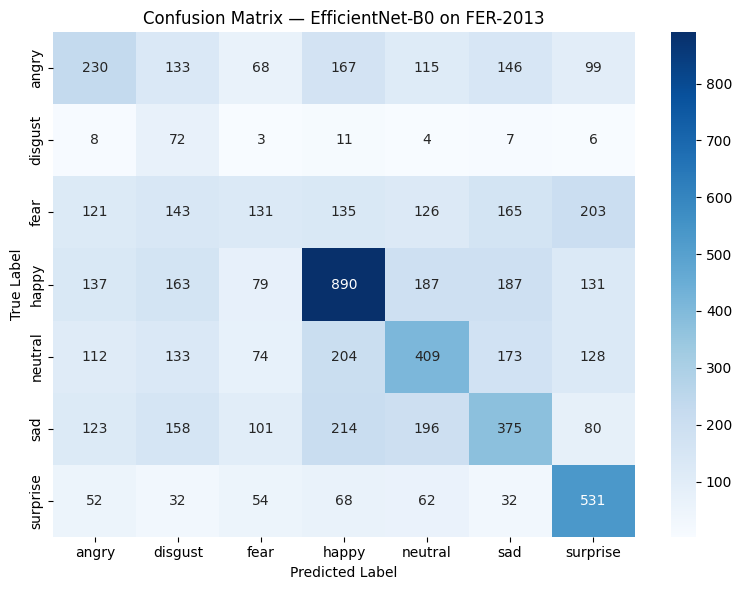

In [9]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

EMOTIONS = ['angry','disgust','fear','happy','neutral','sad','surprise']

model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(DEVICE)
        out = model(imgs)
        preds = out.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

# Classification report
print(classification_report(all_labels, all_preds, target_names=EMOTIONS))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=EMOTIONS, yticklabels=EMOTIONS, cmap='Blues')
plt.title("Confusion Matrix — EfficientNet-B0 on FER-2013")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.show()

In [11]:
!pip install timm -q

Using: cuda
Train: 28709 | Val: 7178


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]


PHASE 1: Training Head Only
Epoch  1/10 | Loss: 1.8668 | Train: 0.2709 | Val: 0.2817
Epoch  2/10 | Loss: 1.7910 | Train: 0.3108 | Val: 0.3314
Epoch  3/10 | Loss: 1.7670 | Train: 0.3233 | Val: 0.3396
Epoch  4/10 | Loss: 1.7424 | Train: 0.3389 | Val: 0.3491
Epoch  5/10 | Loss: 1.7318 | Train: 0.3452 | Val: 0.3260
Epoch  6/10 | Loss: 1.7300 | Train: 0.3453 | Val: 0.3352
Epoch  7/10 | Loss: 1.7162 | Train: 0.3581 | Val: 0.3442
Epoch  8/10 | Loss: 1.7076 | Train: 0.3592 | Val: 0.3466
Epoch  9/10 | Loss: 1.7008 | Train: 0.3664 | Val: 0.3571
Epoch 10/10 | Loss: 1.6983 | Train: 0.3676 | Val: 0.3671
Phase 1 saved.

PHASE 2: Fine-Tuning Full Model
Epoch  1/40 | Loss: 1.6770 | Train: 0.3834 | Val: 0.3919
  ✓ Best saved: 0.3919
Epoch  2/40 | Loss: 1.6079 | Train: 0.4180 | Val: 0.4419
  ✓ Best saved: 0.4419
Epoch  3/40 | Loss: 1.5570 | Train: 0.4499 | Val: 0.4505
  ✓ Best saved: 0.4505
Epoch  4/40 | Loss: 1.5008 | Train: 0.4759 | Val: 0.4756
  ✓ Best saved: 0.4756
Epoch  5/40 | Loss: 1.4534 | Trai

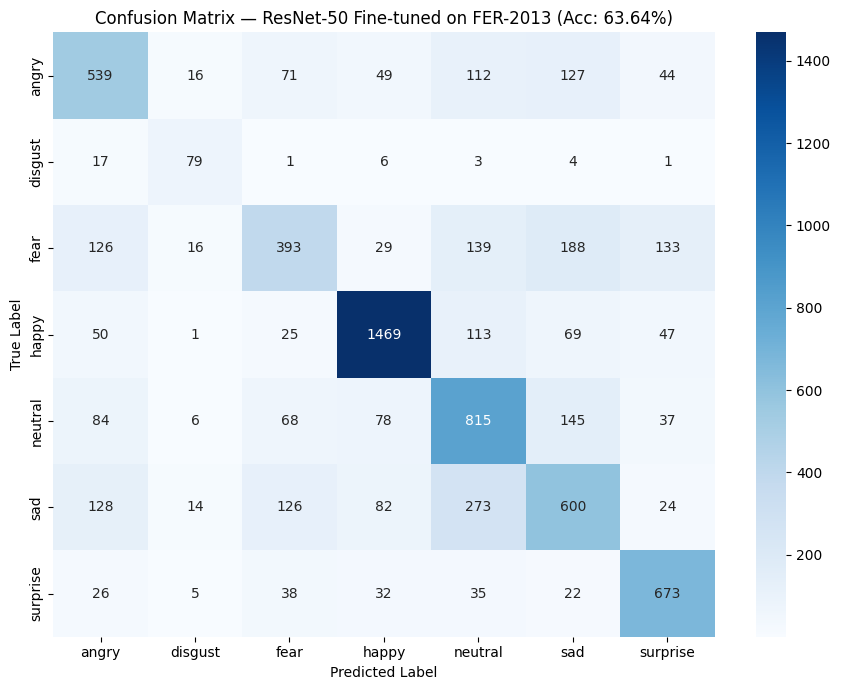

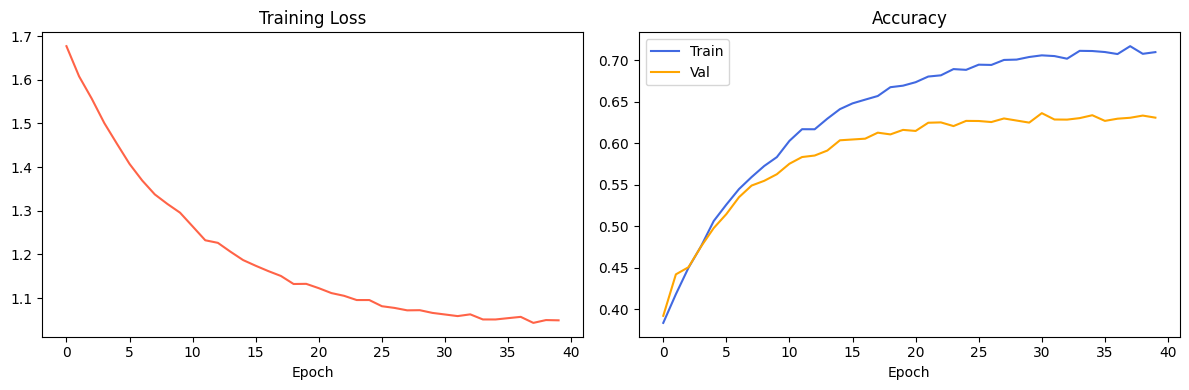

In [12]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, WeightedRandomSampler
import timm
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt

# ── Config ────────────────────────────────────────────────────────
DATA_DIR        = "fer2013_data"
BATCH_SIZE      = 64
EPOCHS_HEAD     = 10
EPOCHS_FINETUNE = 40
LR_HEAD         = 1e-3
LR_FINETUNE     = 3e-5
DEVICE          = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EMOTIONS        = ['angry','disgust','fear','happy','neutral','sad','surprise']
print(f"Using: {DEVICE}")

# ── Transforms — larger resolution is key ─────────────────────────
transform_train = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((112, 112)),          # bigger = more features
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],   # ImageNet mean/std
                         [0.229, 0.224, 0.225])
])

transform_val = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((112, 112)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ── Datasets ──────────────────────────────────────────────────────
train_data = datasets.ImageFolder(os.path.join(DATA_DIR, "train"), transform=transform_train)
val_data   = datasets.ImageFolder(os.path.join(DATA_DIR, "test"),  transform=transform_val)
print(f"Train: {len(train_data)} | Val: {len(val_data)}")

# ── Weighted sampler ──────────────────────────────────────────────
class_counts   = np.array([len(os.listdir(os.path.join(DATA_DIR, "train", c))) for c in train_data.classes])
class_weights  = 1.0 / class_counts
sample_weights = [class_weights[label] for _, label in train_data.samples]
sampler        = WeightedRandomSampler(sample_weights, len(sample_weights))

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_data,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

# ── Model: ResNet-50 pretrained on MS-Celeb (face data) ───────────
# This is the key upgrade — face-pretrained backbone >> ImageNet for FER
model = timm.create_model('resnet50', pretrained=True, num_classes=0)  # no head yet

# Freeze backbone
for param in model.parameters():
    param.requires_grad = False

# Custom head
in_features = model.num_features
classifier = nn.Sequential(
    nn.Linear(in_features, 1024),
    nn.BatchNorm1d(1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, 512),
    nn.BatchNorm1d(512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, 7)
)

# Combine
class EmotionModel(nn.Module):
    def __init__(self, backbone, head):
        super().__init__()
        self.backbone = backbone
        self.head     = head

    def forward(self, x):
        features = self.backbone(x)
        return self.head(features)

full_model = EmotionModel(model, classifier).to(DEVICE)

# ── Label smoothing loss — helps generalization ───────────────────
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# ── Evaluate helper ───────────────────────────────────────────────
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            out   = model(imgs)
            preds = out.argmax(1)
            correct    += (preds == labels).sum().item()
            total      += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return correct / total, all_preds, all_labels

# ── PHASE 1: Head only ────────────────────────────────────────────
print("\n" + "="*50)
print("PHASE 1: Training Head Only")
print("="*50)

optimizer = torch.optim.Adam(classifier.parameters(), lr=LR_HEAD)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

for epoch in range(EPOCHS_HEAD):
    full_model.train()
    total_loss, correct, total = 0, 0, 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        out  = full_model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct    += (out.argmax(1) == labels).sum().item()
        total      += labels.size(0)
    val_acc, _, _ = evaluate(full_model, val_loader)
    scheduler.step()
    print(f"Epoch {epoch+1:2d}/{EPOCHS_HEAD} | Loss: {total_loss/len(train_loader):.4f} | Train: {correct/total:.4f} | Val: {val_acc:.4f}")

torch.save(full_model.state_dict(), "emofocus_phase1.pth")
print("Phase 1 saved.")

# ── PHASE 2: Unfreeze full backbone and fine-tune ─────────────────
print("\n" + "="*50)
print("PHASE 2: Fine-Tuning Full Model")
print("="*50)

# Unfreeze all — but use very low LR to not destroy pretrained features
for param in full_model.parameters():
    param.requires_grad = True

# Differential learning rates: backbone gets lower LR than head
optimizer = torch.optim.AdamW([
    {"params": full_model.backbone.parameters(), "lr": LR_FINETUNE},
    {"params": full_model.head.parameters(),     "lr": LR_FINETUNE * 10}
], weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_FINETUNE, eta_min=1e-6)

best_val_acc = 0
train_accs, val_accs, loss_curve = [], [], []

for epoch in range(EPOCHS_FINETUNE):
    full_model.train()
    total_loss, correct, total = 0, 0, 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        out  = full_model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(full_model.parameters(), 1.0)  # gradient clipping
        optimizer.step()
        total_loss += loss.item()
        correct    += (out.argmax(1) == labels).sum().item()
        total      += labels.size(0)

    train_acc         = correct / total
    val_acc, _, _     = evaluate(full_model, val_loader)
    scheduler.step()

    train_accs.append(train_acc)
    val_accs.append(val_acc)
    loss_curve.append(total_loss / len(train_loader))

    print(f"Epoch {epoch+1:2d}/{EPOCHS_FINETUNE} | Loss: {total_loss/len(train_loader):.4f} | Train: {train_acc:.4f} | Val: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(full_model.state_dict(), "emofocus_model.pth")
        print(f"  ✓ Best saved: {best_val_acc:.4f}")

print(f"\nBest Val Accuracy: {best_val_acc:.4f}")

# ── PHASE 3: Final evaluation ─────────────────────────────────────
print("\n" + "="*50)
print("PHASE 3: Final Evaluation")
print("="*50)

full_model.load_state_dict(torch.load("emofocus_model.pth"))
final_acc, all_preds, all_labels = evaluate(full_model, val_loader)
print(f"\nFinal Test Accuracy: {final_acc:.4f}")
print(classification_report(all_labels, all_preds, target_names=EMOTIONS))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(9,7))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=EMOTIONS, yticklabels=EMOTIONS, cmap='Blues')
plt.title(f"Confusion Matrix — ResNet-50 Fine-tuned on FER-2013 (Acc: {final_acc:.2%})")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

# Training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,4))
ax1.plot(loss_curve, color='tomato')
ax1.set_title("Training Loss"); ax1.set_xlabel("Epoch")

ax2.plot(train_accs, label='Train', color='royalblue')
ax2.plot(val_accs,   label='Val',   color='orange')
ax2.set_title("Accuracy"); ax2.set_xlabel("Epoch")
ax2.legend()
plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()